In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

### Se pide, usando regresión lineal:

Dibujar con una línea la relación que hay entre la altura y la edad de los alumnos de esta clase: 

In [2]:
lista_alumnos = [("Leonardo S", 24, 1.82), 
                 ("Piero T", 25, 1.71), 
                 ("Marta B", 35, 1.66), 
                 ("Silvia P", 37, 1.63), 
                 ("Faro Z", 29, 1.90), 
                 ("Miguel N", 27, 1.80), 
                 ("Alejandro M", 28, 1.70), 
                 ("Cristina M", 32, 1.60), 
                 ("Francisco P", 36, 1.74), 
                 ("Jorge D", 45, 1.72), 
                 ("Jesús L", 41, 1.65), 
                 ("Marta G", 30, 1.65), 
                 ("Jennifer S", 40, 1.60), 
                 ("Diego I", 39, 1.80), 
                 ("Antonio C", 23, 1.77), 
                 ("Juan M", 32, 1.75), 
                 ("David S", 27, 1.70), 
                 ("Antonio J", 34, 1.80), 
                 ("Carlos H", 27, 1.77), 
                 ("Erik U", 28, 1.70), 
                 ("Marcos L", 35, 1.80)] 

In [3]:
df_lista_alumnos = pd.DataFrame(lista_alumnos,columns=["Nombre", "Edad", "Altura"])
df_lista_alumnos

,Nombre,Edad,Altura
0,Leonardo S,24,1.82
1,Piero T,25,1.71
2,Marta B,35,1.66
3,Silvia P,37,1.63
4,Faro Z,29,1.90
5,Miguel N,27,1.80
6,Alejandro M,28,1.70
7,Cristina M,32,1.60
8,Francisco P,36,1.74
9,Jorge D,45,1.72


Text(0, 0.5, 'Altura')

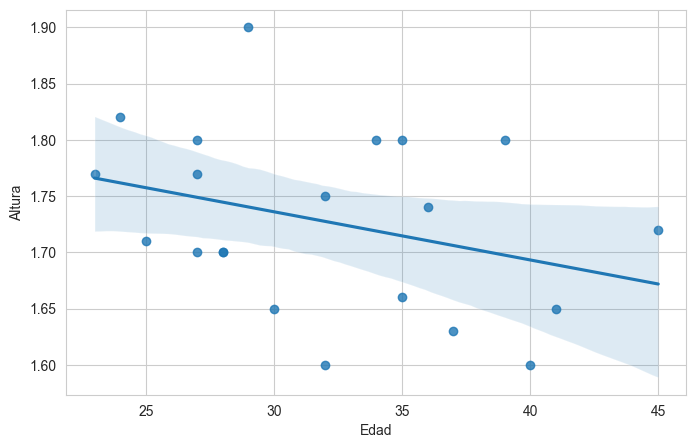

In [4]:
plt.figure(figsize=(8, 5))
sns.regplot(x=df_lista_alumnos["Edad"], y=df_lista_alumnos["Altura"])
plt.xlabel("Edad")
plt.ylabel("Altura")

### ¿Es una buena técnica para este tipo de problemas? Demuéstralo antes de entrenar un modelo con un análisis descriptivo.

##### CORRELACIONES ENTRE VARIABLES

In [5]:
df_lista_alumnos.corr(numeric_only=True)

,Edad,Altura
Edad,1.000000,-0.329275
Altura,-0.329275,1.000000


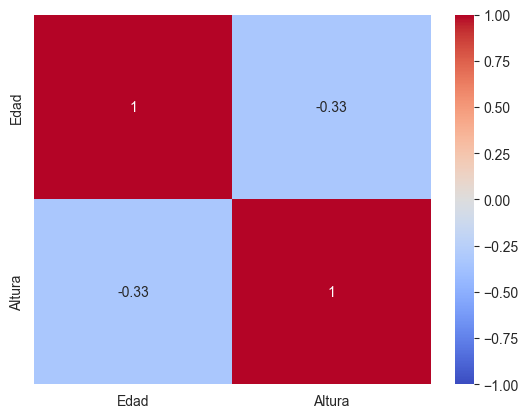

In [6]:
sns.heatmap(df_lista_alumnos.corr(numeric_only=True), annot=True, vmin=-1, cmap='coolwarm');

##### FUNCIONES DE AGREGACIÓN TOTALES

In [7]:
# Media de la edad
print("Edad media: ", round(df_lista_alumnos["Edad"].mean(), 2))

Edad media:  32.1


In [8]:
# Media de la altura
print("Altura media: ", round(df_lista_alumnos["Altura"].mean(), 2))

Altura media:  1.73


In [9]:
# Mediana de la edad
print("Mediana de la edad: ", round(df_lista_alumnos["Edad"].median(), 2))

Mediana de la edad:  32.0


In [10]:
# Mediana de la altura
print("Mediana de la altura: ", round(df_lista_alumnos["Altura"].median(), 2))

Mediana de la altura:  1.72


##### FUNCIONES DE AGREGACIÓN POR RANGO DE EDAD 

- Rango 1: alumnos con edad menor o igual a 30 años
- Rango 2: alumnos con más a 30 años

In [11]:
# Edad mínima
print("Edad mínima: ", df_lista_alumnos["Edad"].min())

# Edad máxima
print("Edad mínima: ", df_lista_alumnos["Edad"].max())

Edad mínima:  23
Edad mínima:  45


In [13]:
df_lista_alumnos["RangoEdad"] = pd.cut(
    df_lista_alumnos["Edad"],
    bins=[0, 30, 100], 
    labels=["<= 30 años", "> 30 años"]
)

print(df_lista_alumnos)


         Nombre  Edad  Altura   RangoEdad
0    Leonardo S    24    1.82  <= 30 años
1       Piero T    25    1.71  <= 30 años
2       Marta B    35    1.66   > 30 años
3      Silvia P    37    1.63   > 30 años
4        Faro Z    29    1.90  <= 30 años
5      Miguel N    27    1.80  <= 30 años
6   Alejandro M    28    1.70  <= 30 años
7    Cristina M    32    1.60   > 30 años
8   Francisco P    36    1.74   > 30 años
9       Jorge D    45    1.72   > 30 años
10      Jesús L    41    1.65   > 30 años
11      Marta G    30    1.65  <= 30 años
12   Jennifer S    40    1.60   > 30 años
13      Diego I    39    1.80   > 30 años
14    Antonio C    23    1.77  <= 30 años
15       Juan M    32    1.75   > 30 años
16      David S    27    1.70  <= 30 años
17    Antonio J    34    1.80   > 30 años
18     Carlos H    27    1.77  <= 30 años
19       Erik U    28    1.70  <= 30 años
20     Marcos L    35    1.80   > 30 años


In [14]:
df_lista_alumnos.groupby("RangoEdad").agg({
    "Edad": ["count"],
    "Altura": ["mean", "std"]
})

C:\Users\Administrador\AppData\Local\Temp\ipykernel_14320\3949996618.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_lista_alumnos.groupby("RangoEdad").agg({


Edad    Altura          
           count      mean       std
RangoEdad                           
<= 30 años    10  1.752000  0.074356
> 30 años     11  1.704545  0.079544

##### CONCLUSIONES

Los datos muestran una correlación negativa débil entre la edad y la altura (–0.33). Además, al separar los alumnos por rangos de edad, se observa que el grupo de ≤ 30 años presenta una altura media mayor que el grupo de > 30 años, lo cual refuerza esta tendencia.

En el gráfico de dispersión, la línea de regresión también indica una ligera disminución de la altura conforme aumenta la edad. Por ello, podría considerarse que la regresión lineal es una técnica razonable para analizar esta relación.

### Entrena un modelo de regresión lineal

In [27]:
X = df_lista_alumnos[["Edad"]]
y = df_lista_alumnos["Altura"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.30, random_state=42)

print("Total features shape:", X.shape)
print("Train features shape:", X_train.shape)
print("Train target shape:", y_train.shape)
print("Test features shape:", X_test.shape)
print("Test target shape:", y_test.shape)

Total features shape: (21, 1)
Train features shape: (14, 1)
Train target shape: (14,)
Test features shape: (7, 1)
Test target shape: (7,)


In [25]:
#creating LinearRegression Object
lm = LinearRegression()

In [17]:
#Training the Data Model
lm.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
pred = lm.predict([[45]])
pred 

c:\Users\Administrador\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1.66578785])

### ¿Qué error se comete? Calcula los errores que está cometiendo tu modelo de forma manual con python. Aparte, usa las métricas de sklearn MAE, MAPE, MSE y el RMSE.

In [19]:
predictions = lm.predict(X_test)
predictions

array([1.75272915, 1.71132853, 1.71960865, 1.74858908, 1.7030484 ,
       1.74030896, 1.72788877])

In [20]:
lm.score(X_test, y_test)

-0.19742015635643928

In [21]:
errors = y_test - predictions        
mae = np.mean(np.abs(errors))       
mse = np.mean(errors**2)             
rmse = np.sqrt(mse)                  
mape = np.mean(np.abs(errors / y_test)) * 100  

print("Errores individuales en el test: \n", errors)
print("-" * 50)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAPE:", mape, "%")

Errores individuales en el test: 
 0     0.067271
17    0.088671
15    0.030391
1    -0.038589
8     0.036952
5     0.059691
11   -0.077889
Name: Altura, dtype: float64
--------------------------------------------------
MAE: 0.05706488156539665
MSE: 0.0036851216240520687
RMSE: 0.060705202611078306
MAPE: 3.2537242071442014 %


In [22]:
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 0.05706488156539665
MSE: 0.0036851216240520687
RMSE: 0.060705202611078306
